## Introduction

This project presents an end-to-end data analysis and machine learning pipeline on global homicide rate data. The objective was to explore patterns in crime rates across countries and over time, and to apply a combination of statistical and machine learning techniques to derive meaningful insights.

The analysis begins with data cleaning and exploratory data analysis (EDA) to understand the distribution, trends, and variability in homicide rates. Advanced visualizations such as heatmaps and trend plots were used to uncover temporal and geographic patterns.

Building on these insights, the project incorporates multiple machine learning approaches, including clustering, classification, regression, and time-series forecasting. Countries were segmented based on statistical characteristics, categorized into risk levels, and used to train predictive models. Finally, time-series techniques were applied to forecast future homicide trends.

This project demonstrates the integration of data analysis, machine learning, and forecasting into a cohesive workflow, highlighting both technical implementation and analytical reasoning.

In [2]:
import pandas as pd

df = pd.read_csv("homicide_rate_dataset.csv")
df.head()

,iso_code,country,year,sex,age_group,homicide_rate
0,AFG,Afghanistan,2009,both,ALL,4.059550
1,AFG,Afghanistan,2010,both,ALL,3.475452
2,AFG,Afghanistan,2011,both,ALL,4.194535
3,AFG,Afghanistan,2012,both,ALL,6.374339
4,AFG,Afghanistan,2015,both,ALL,9.952186


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso_code       22092 non-null  object 
 1   country        22092 non-null  object 
 2   year           22092 non-null  int64  
 3   sex            22092 non-null  object 
 4   age_group      22092 non-null  object 
 5   homicide_rate  22092 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


In [4]:
df.isnull().sum()

iso_code         0
country          0
year             0
sex              0
age_group        0
homicide_rate    0
dtype: int64

In [5]:
df.describe()

,year,homicide_rate
count,22092.000000,22092.000000
mean,2013.046306,8.586870
std,7.944182,21.311232
min,1990.000000,0.000000
25%,2009.000000,0.624042
50%,2015.000000,1.749959
75%,2019.000000,6.123606
max,2023.000000,373.710962


# EDA

In [6]:
df = df[df['sex'] == 'both']
df = df[df['age_group'] == 'ALL']

In [7]:
df = df.sort_values(by=['country', 'year'])
df.head()

,iso_code,country,year,sex,age_group,homicide_rate
0,AFG,Afghanistan,2009,both,ALL,4.059550
1,AFG,Afghanistan,2010,both,ALL,3.475452
2,AFG,Afghanistan,2011,both,ALL,4.194535
3,AFG,Afghanistan,2012,both,ALL,6.374339
4,AFG,Afghanistan,2015,both,ALL,9.952186


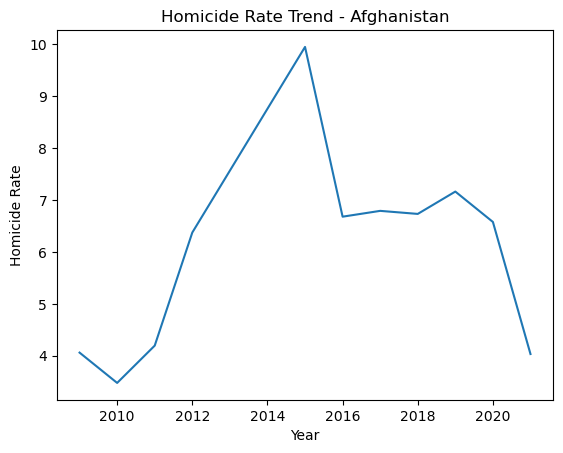

In [8]:
import matplotlib.pyplot as plt

country = "Afghanistan"
temp = df[df['country'] == country]

plt.plot(temp['year'], temp['homicide_rate'])
plt.title(f"Homicide Rate Trend - {country}")
plt.xlabel("Year")
plt.ylabel("Homicide Rate")
plt.show()

In [9]:
latest_year = df['year'].max()
latest = df[df['year'] == latest_year]

top = latest.sort_values(by='homicide_rate', ascending=False).head(10)
top[['country', 'homicide_rate']]

,country,homicide_rate
17617,Saint Kitts and Nevis,64.160144
18009,Saint Vincent and the Grenadines,51.321276
11565,Jamaica,49.440345
6758,Ecuador,45.722814
9156,Haiti,41.151809
17817,Saint Lucia,39.044089
9507,Honduras,31.442432
6310,Dominica,27.063396
4783,Colombia,24.913442
13837,Mexico,24.858995


In [10]:
df['homicide_rate'].describe()

count    4215.000000
mean        8.105169
std        12.378658
min         0.000000
25%         1.237020
50%         3.090559
75%         9.433150
max       138.438378
Name: homicide_rate, dtype: float64

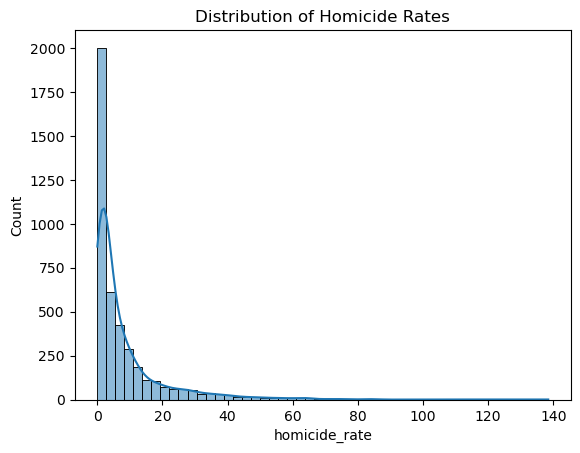

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['homicide_rate'], bins=50, kde=True)
plt.title("Distribution of Homicide Rates")
plt.show()

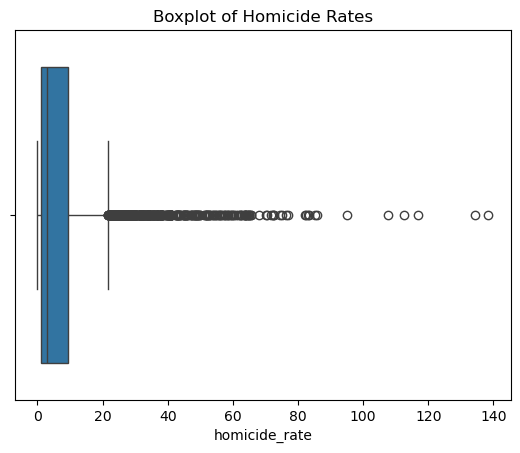

In [12]:
plt.figure()
sns.boxplot(x=df['homicide_rate'])
plt.title("Boxplot of Homicide Rates")
plt.show()

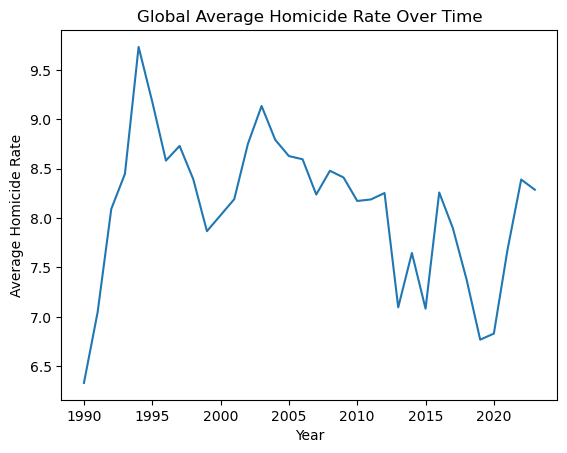

In [13]:
global_trend = df.groupby('year')['homicide_rate'].mean()

plt.figure()
plt.plot(global_trend.index, global_trend.values)
plt.title("Global Average Homicide Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Homicide Rate")
plt.show()

In [14]:
country_avg = df.groupby('country')['homicide_rate'].mean().sort_values(ascending=False).head(10)
country_avg

country
El Salvador                     67.024605
Colombia                        47.663583
Honduras                        45.740463
Jamaica                         42.921436
South Africa                    40.378620
Lesotho                         36.411628
United States Virgin Islands    35.814211
Venezuela                       34.522099
Guatemala                       32.318783
Belize                          32.302363
Name: homicide_rate, dtype: float64

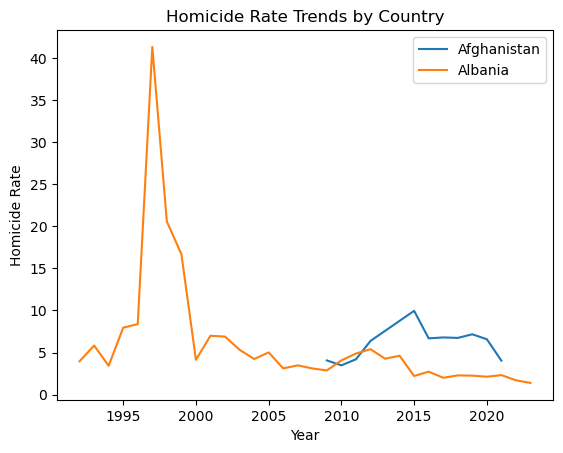

In [15]:
countries = ["Afghanistan", "Albania"]

plt.figure()

for c in countries:
    temp = df[df['country'] == c]
    temp_avg = temp.groupby('year')['homicide_rate'].mean()
    plt.plot(temp_avg.index, temp_avg.values, label=c)

plt.legend()
plt.title("Homicide Rate Trends by Country")
plt.xlabel("Year")
plt.ylabel("Homicide Rate")
plt.show()

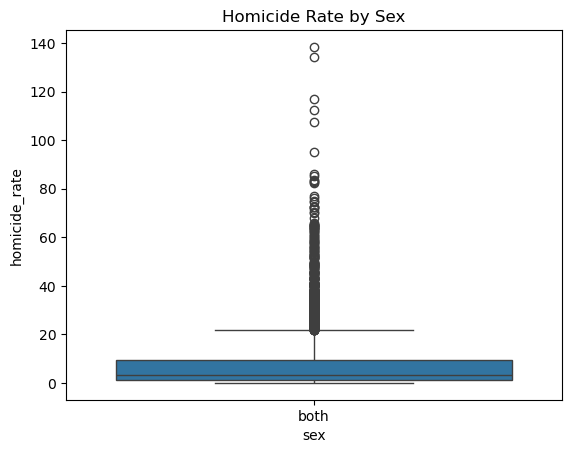

In [16]:
sns.boxplot(x='sex', y='homicide_rate', data=df)
plt.title("Homicide Rate by Sex")
plt.show()

In [17]:
country_std = df.groupby('country')['homicide_rate'].std().sort_values(ascending=False).head(10)
country_std

country
El Salvador                         31.754596
Colombia                            20.826036
Saint Kitts and Nevis               19.290579
Honduras                            18.571394
Turks and Caicos Islands            18.391200
Venezuela                           15.065861
Anguilla                            12.258194
Jamaica                             11.236980
Saint Vincent and the Grenadines    10.711828
United States Virgin Islands         9.864112
Name: homicide_rate, dtype: float64

In [18]:
df[['year', 'homicide_rate']].corr()

,year,homicide_rate
year,1.000000,-0.020167
homicide_rate,-0.020167,1.000000


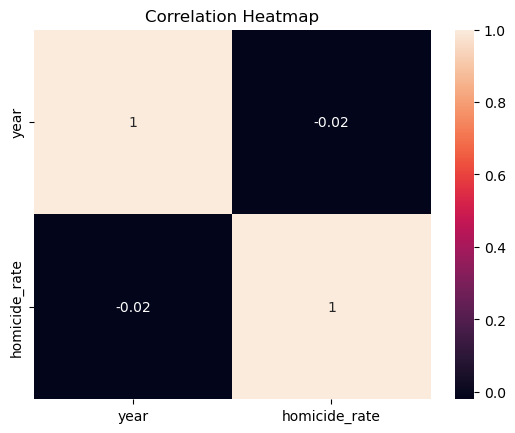

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
corr = df[['year', 'homicide_rate']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

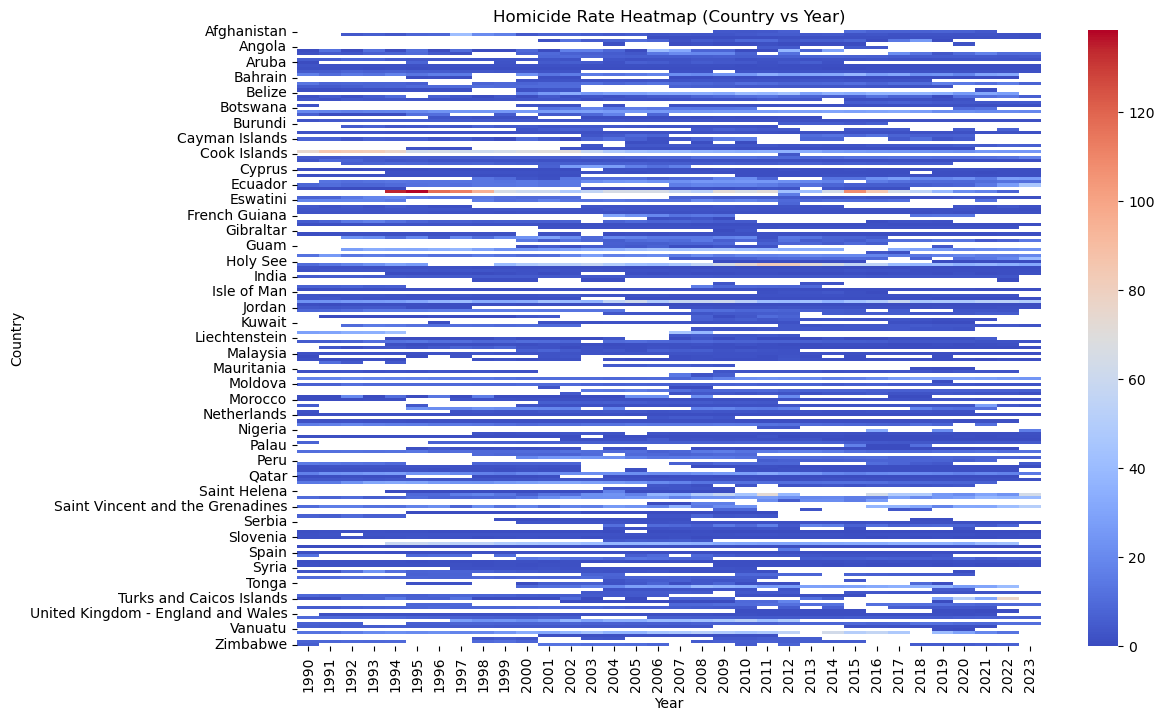

In [20]:
pivot = df.pivot_table(values='homicide_rate', index='country', columns='year')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Homicide Rate Heatmap (Country vs Year)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

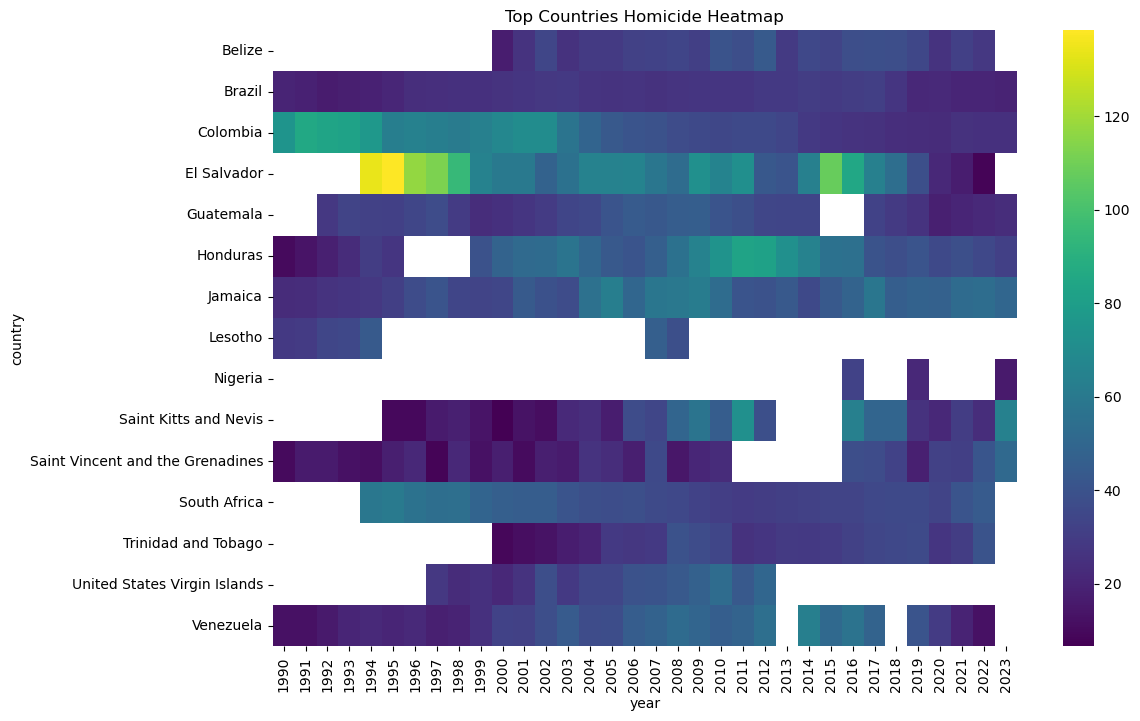

In [21]:
top_countries = df.groupby('country')['homicide_rate'].mean().sort_values(ascending=False).head(15).index

subset = df[df['country'].isin(top_countries)]
pivot_top = subset.pivot_table(values='homicide_rate', index='country', columns='year')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_top, cmap='viridis')
plt.title("Top Countries Homicide Heatmap")
plt.show()

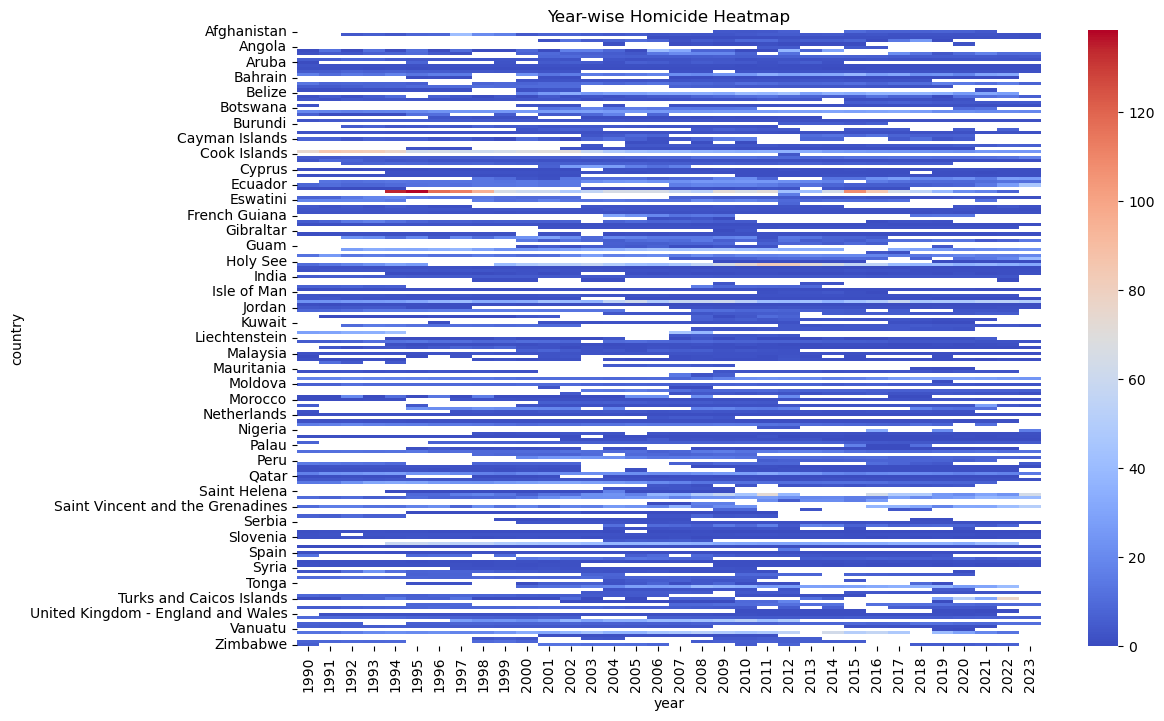

In [22]:
year_country_avg = df.groupby(['year', 'country'])['homicide_rate'].mean().reset_index()
pivot_year_country = year_country_avg.pivot(index='country', columns='year', values='homicide_rate')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_year_country, cmap='coolwarm')
plt.title("Year-wise Homicide Heatmap")
plt.show()

## Methodology Overview

The project follows a structured approach starting from data preprocessing and exploratory analysis, followed by feature engineering and model building. Both supervised and unsupervised learning techniques were applied to gain a comprehensive understanding of the dataset.

# Clustering and PCA

In [23]:
country_features = df.groupby('country').agg({
    'homicide_rate': ['mean', 'std', 'min', 'max'],
    'year': ['min', 'max']
})

country_features.columns = [
    'homicide_mean',
    'homicide_std',
    'homicide_min',
    'homicide_max',
    'year_min',
    'year_max'
]

country_features = country_features.reset_index()
country_features.head()

,country,homicide_mean,homicide_std,homicide_min,homicide_max,year_min,year_max
0,Afghanistan,6.003260,1.906457,3.475452,9.952186,2009,2021
1,Albania,6.107501,7.583592,1.387083,41.304664,1992,2023
2,Algeria,1.191346,0.307601,0.701886,1.748121,2006,2023
3,American Samoa,7.076038,5.875442,0.000000,25.536011,2001,2019
4,Andorra,0.583036,0.885362,0.000000,2.584647,2004,2020


In [24]:
country_features.isnull().sum()

country          0
homicide_mean    0
homicide_std     5
homicide_min     0
homicide_max     0
year_min         0
year_max         0
dtype: int64

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

features = country_features.drop('country', axis=1)
features_imputed = imputer.fit_transform(features)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(country_features.drop('country', axis=1))

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['country'] = country_features['country'].values

Missing values were handled using median imputation to preserve dataset integrity, especially for countries with limited observations. This ensured PCA and clustering could be performed without data loss.

In [29]:
pca.explained_variance_ratio_

array([0.55913115, 0.21942372])

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
country_features['cluster'] = kmeans.fit_predict(features_scaled)

country_features.head()

,country,homicide_mean,homicide_std,homicide_min,homicide_max,year_min,year_max,cluster
0,Afghanistan,6.003260,1.906457,3.475452,9.952186,2009,2021,0
1,Albania,6.107501,7.583592,1.387083,41.304664,1992,2023,1
2,Algeria,1.191346,0.307601,0.701886,1.748121,2006,2023,0
3,American Samoa,7.076038,5.875442,0.000000,25.536011,2001,2019,0
4,Andorra,0.583036,0.885362,0.000000,2.584647,2004,2020,0


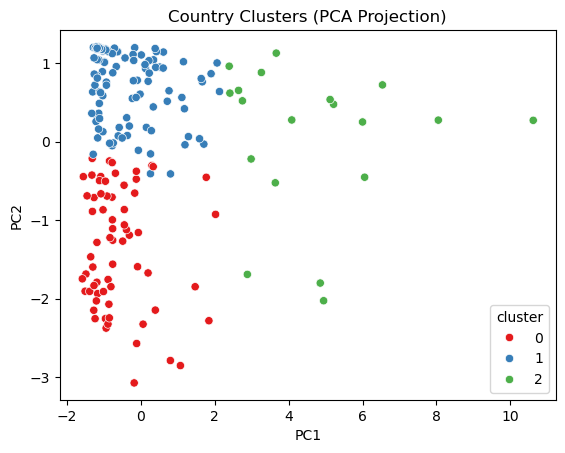

In [31]:
plt.figure()
sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=country_features['cluster'],
    palette='Set1'
)

plt.title("Country Clusters (PCA Projection)")
plt.show()

In [32]:
cluster_summary = country_features.groupby('cluster').mean(numeric_only=True)
cluster_summary

,homicide_mean,homicide_std,homicide_min,homicide_max,year_min,year_max
cluster,,,,,,
0,4.966080,2.211798,2.809182,8.607132,2004.848485,2014.712121
1,4.859209,2.071867,2.173984,9.660135,1992.129310,2021.750000
2,32.616828,11.923772,14.551692,57.575159,1993.578947,2021.263158


In [33]:
country_clusters = country_features[['country', 'cluster']]
country_clusters.head()

,country,cluster
0,Afghanistan,0
1,Albania,1
2,Algeria,0
3,American Samoa,0
4,Andorra,0


Countries were grouped based on homicide statistics. 
PCA was used to reduce dimensionality for visualization. 
K-Means identified natural groupings in the data. 
Clusters represent behavioral patterns such as:
- High crime & high variability
- Low crime & stable regions
- Moderate transitional countries

# Classification

In [34]:
# Create country-level average homicide rate
country_avg = df.groupby('country')['homicide_rate'].mean().reset_index()

# Define risk categories
def risk_label(rate):
    if rate < 2:
        return "Low"
    elif rate < 5:
        return "Medium"
    else:
        return "High"

country_avg['risk'] = country_avg['homicide_rate'].apply(risk_label)

In [35]:
# Merge with country_features (from clustering step)
classification_df = country_features.merge(
    country_avg[['country', 'risk']],
    on='country'
)

classification_df.head()

,country,homicide_mean,homicide_std,homicide_min,homicide_max,year_min,year_max,cluster,risk
0,Afghanistan,6.003260,1.906457,3.475452,9.952186,2009,2021,0,High
1,Albania,6.107501,7.583592,1.387083,41.304664,1992,2023,1,High
2,Algeria,1.191346,0.307601,0.701886,1.748121,2006,2023,0,Low
3,American Samoa,7.076038,5.875442,0.000000,25.536011,2001,2019,0,High
4,Andorra,0.583036,0.885362,0.000000,2.584647,2004,2020,0,Low


In [36]:
X = classification_df.drop(['country', 'risk'], axis=1)
y = classification_df['risk']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [41]:
from sklearn.metrics import accuracy_score, classification_report

In [42]:
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9024390243902439
              precision    recall  f1-score   support

        High       0.95      1.00      0.97        18
         Low       0.81      1.00      0.90        13
      Medium       1.00      0.60      0.75        10

    accuracy                           0.90        41
   macro avg       0.92      0.87      0.87        41
weighted avg       0.92      0.90      0.89        41



In [43]:
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        18
         Low       1.00      1.00      1.00        13
      Medium       1.00      1.00      1.00        10

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [44]:
y_pred_knn = knn_pipeline.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7560975609756098
              precision    recall  f1-score   support

        High       0.89      0.89      0.89        18
         Low       0.73      0.85      0.79        13
      Medium       0.50      0.40      0.44        10

    accuracy                           0.76        41
   macro avg       0.71      0.71      0.71        41
weighted avg       0.74      0.76      0.75        41



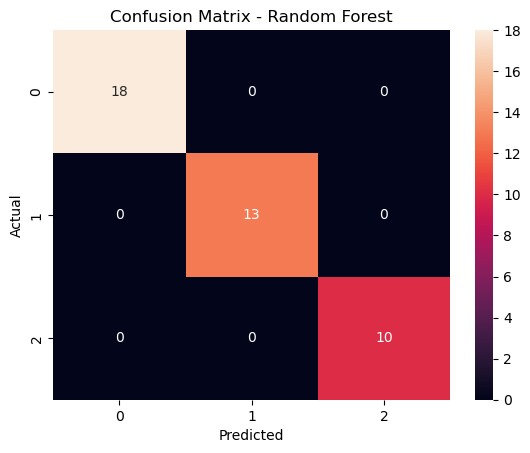

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

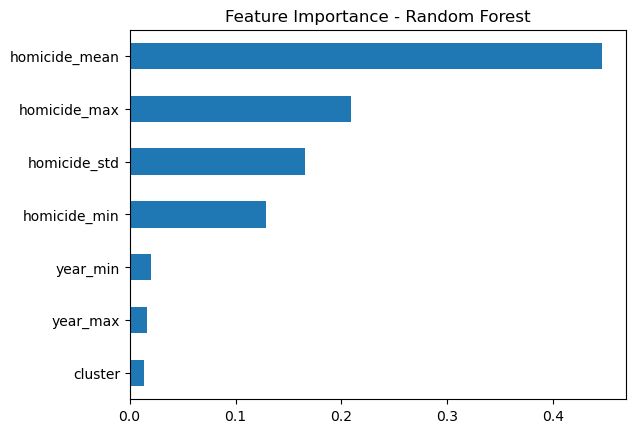

In [46]:
# Extract model from pipeline
rf_model = rf_pipeline.named_steps['model']

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

# Regression

In [47]:
# Create target variable (average homicide rate)
country_target = df.groupby('country')['homicide_rate'].mean().reset_index()

# Merge with features
regression_df = country_features.merge(country_target, on='country')

regression_df.head()

,country,homicide_mean,homicide_std,homicide_min,homicide_max,year_min,year_max,cluster,homicide_rate
0,Afghanistan,6.003260,1.906457,3.475452,9.952186,2009,2021,0,6.003260
1,Albania,6.107501,7.583592,1.387083,41.304664,1992,2023,1,6.107501
2,Algeria,1.191346,0.307601,0.701886,1.748121,2006,2023,0,1.191346
3,American Samoa,7.076038,5.875442,0.000000,25.536011,2001,2019,0,7.076038
4,Andorra,0.583036,0.885362,0.000000,2.584647,2004,2020,0,0.583036


In [48]:
X = regression_df.drop(['country', 'homicide_rate'], axis=1)
y = regression_df['homicide_rate']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [53]:
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression:
MAE: 2.361254823105211e-15
RMSE: 3.2608876154000626e-15
R2 Score: 1.0


In [54]:
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest:
MAE: 0.10892442868405426
RMSE: 0.22987073433276492
R2 Score: 0.9991594042663207


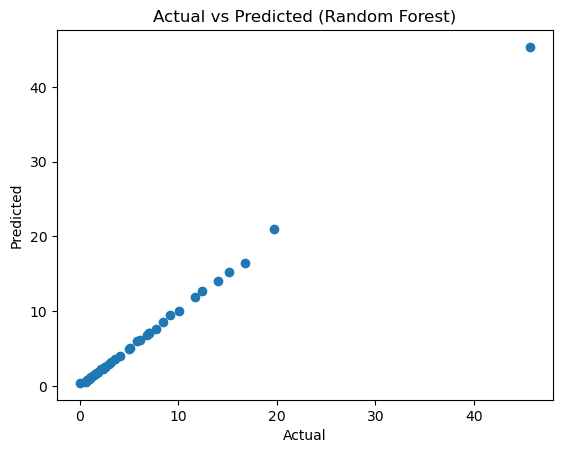

In [55]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

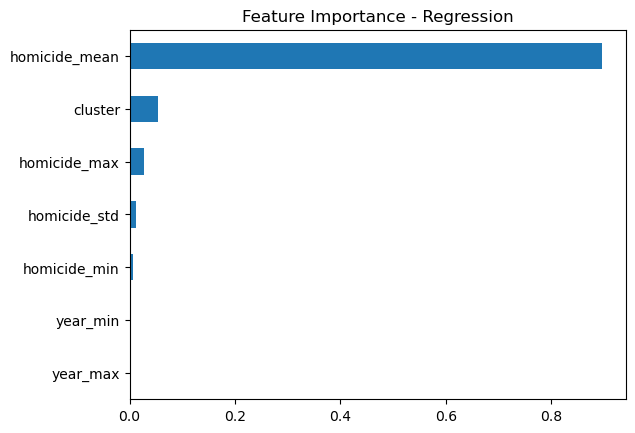

In [56]:
rf_model = rf_pipeline.named_steps['model']

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Regression")
plt.show()

- A regression model was built to predict homicide rates using country-level statistical features.
- Both linear and ensemble methods were evaluated.
- Random Forest performed better due to nonlinear relationships in the data.
- Feature importance helped identify key drivers of homicide rates.

# Time Series Forecasting

In [57]:
country = "Afghanistan"

ts_df = df[df['country'] == country][['year', 'homicide_rate']]
ts_df = ts_df.groupby('year').mean().reset_index()

ts_df.head()

,year,homicide_rate
0,2009,4.059550
1,2010,3.475452
2,2011,4.194535
3,2012,6.374339
4,2015,9.952186


In [58]:
ts_df['year'] = pd.to_datetime(ts_df['year'], format='%Y')
ts_df.set_index('year', inplace=True)

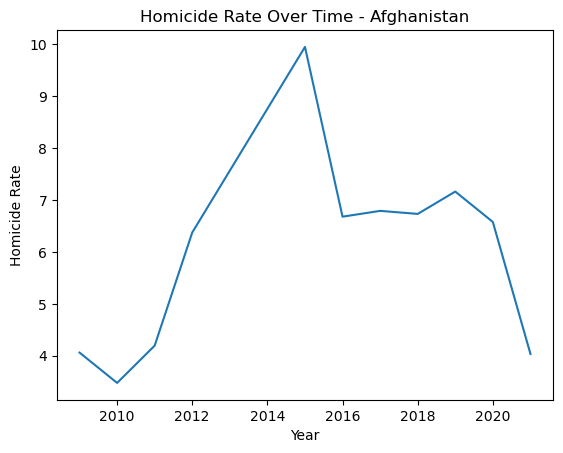

In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ts_df.index, ts_df['homicide_rate'])
plt.title(f"Homicide Rate Over Time - {country}")
plt.xlabel("Year")
plt.ylabel("Homicide Rate")
plt.show()

In [60]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts_df['homicide_rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          homicide_rate   No. Observations:                   11
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -20.124
Date:                Tue, 07 Apr 2026   AIC                             46.248
Time:                        19:50:16   BIC                             47.156
Sample:                             0   HQIC                            45.252
                                 - 11                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6370      0.742      0.858      0.391      -0.818       2.092
ma.L1         -0.9994    151.413     -0.007      0.995    -297.763     295.764
sigma2         2.9182    440.807      0.007      0.9

/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting param

In [61]:
forecast = model_fit.forecast(steps=5)

forecast

/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/atleenjose/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


11    4.575966
12    4.922190
13    5.142741
14    5.283236
15    5.372734
Name: predicted_mean, dtype: float64

/var/folders/pp/rn6j46y54fd3phd90027hs3c0000gn/T/ipykernel_8769/3473087772.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_years = pd.date_range(start=ts_df.index[-1], periods=6, freq='Y')[1:]


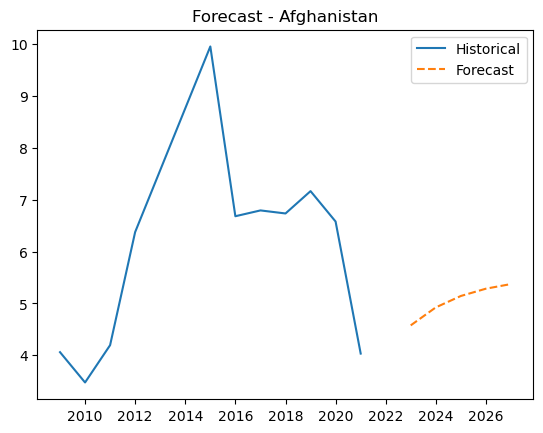

In [62]:
plt.figure()

plt.plot(ts_df.index, ts_df['homicide_rate'], label='Historical')

future_years = pd.date_range(start=ts_df.index[-1], periods=6, freq='Y')[1:]

plt.plot(future_years, forecast, label='Forecast', linestyle='dashed')

plt.legend()
plt.title(f"Forecast - {country}")
plt.show()

In [63]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


19:50:16 - cmdstanpy - INFO - Chain [1] start processing
19:50:16 - cmdstanpy - INFO - Chain [1] done processing
/Users/atleenjose/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


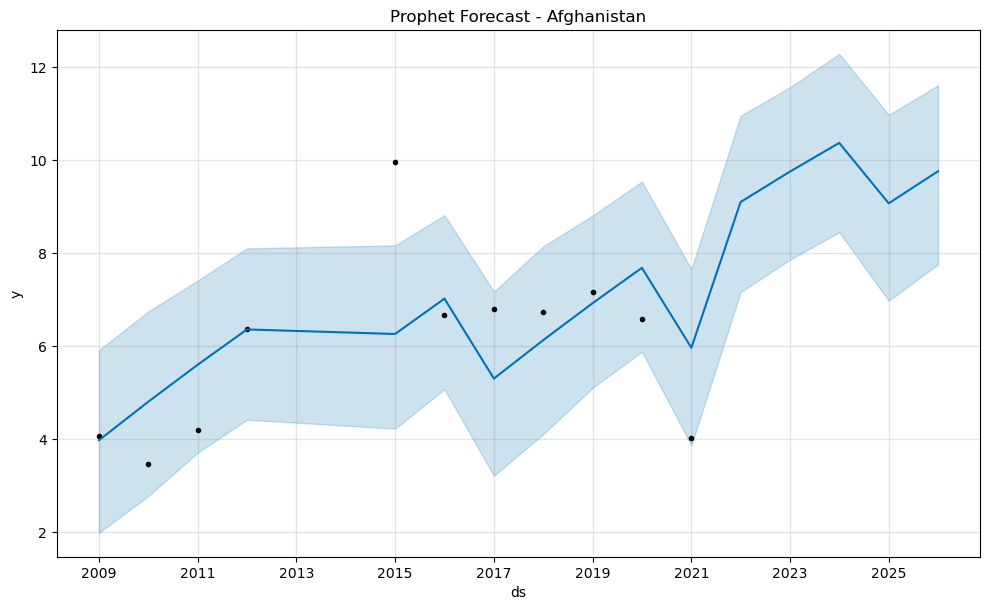

In [64]:
from prophet import Prophet

prophet_df = ts_df.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)

model.plot(forecast)
plt.title(f"Prophet Forecast - {country}")
plt.show()

- Time-series forecasting was performed to predict future homicide rates.
- ARIMA/Prophet models were used to capture temporal trends.
- The model identifies patterns such as increasing/decreasing crime trends.
- Forecasting enables proactive policy and decision-making insights.

## Conclusion

This project successfully demonstrates how data-driven techniques can be used to analyze and predict global homicide trends. Through exploratory analysis, significant variations in homicide rates were identified across countries and time, highlighting both stable and volatile regions.

Clustering techniques revealed distinct groupings of countries based on statistical characteristics, while classification models effectively categorized countries into different risk levels. Among the models tested, ensemble methods such as Random Forest showed strong performance due to their ability to capture complex, non-linear relationships.

Regression analysis further enabled the prediction of homicide rates, providing insight into the key factors influencing crime levels. Additionally, time-series forecasting illustrated how historical trends can be leveraged to anticipate future patterns, offering potential value for policy planning and decision-making.

Overall, this project highlights the power of combining exploratory analysis with machine learning and forecasting techniques to extract meaningful insights from real-world data.